In [ ]:
# Install the library that lets us download GEO datasets directly
!pip install GEOparse
import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("All libraries loaded successfully")

All libraries loaded successfully


In [ ]:
gse = GEOparse.get_GEO(geo="GSE45827", destdir="./")

print("Dataset downloaded successfully")
print(f"Number of samples: {len(gse.gsms)}")

28-Jun-2026 12:19:52 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
28-Jun-2026 12:19:52 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE45nnn/GSE45827/soft/GSE45827_family.soft.gz to ./GSE45827_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE45nnn/GSE45827/soft/GSE45827_family.soft.gz to ./GSE45827_family.soft.gz
100%|██████████| 40.1M/40.1M [00:00<00:00, 81.9MB/s]
28-Jun-2026 12:19:53 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
28-Jun-2026 12:19:53 DEBUG downloader - Moving /tmp/tmpu384o27q to /content/GSE45827_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpu384o27q to /content/GSE45827_family.soft.gz
28-Jun-2026 12:19:53 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE45nnn/GSE45827/soft/GSE45827_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE45nnn/GSE45

Dataset downloaded successfully
Number of samples: 155


In [ ]:
# Extract expression values for all samples into one table
expression_data = pd.DataFrame({
    gsm_name: gsm.table.set_index("ID_REF")["VALUE"]
    for gsm_name, gsm in gse.gsms.items()
})

print(f"Expression matrix shape: {expression_data.shape}")
print("Rows = genes, Columns = samples")
print(expression_data.head())

Expression matrix shape: (29873, 155)
Rows = genes, Columns = samples
           GSM1116084  GSM1116085  GSM1116086  GSM1116087  GSM1116088  \
ID_REF                                                                  
1007_s_at     9.47065     9.67440    10.20800    10.11420    11.16360   
1053_at       8.36311     8.72194     7.78601     9.44537     7.71242   
117_at        5.95426     7.02523     6.39671     4.56023     5.29008   
1294_at       6.02119     7.24581     6.85310     5.42786     7.51120   
1316_at       3.22997     3.29352     3.26204     3.34766     3.59086   

           GSM1116089  GSM1116090  GSM1116091  GSM1116092  GSM1116093  ...  \
ID_REF                                                                 ...   
1007_s_at    10.00690     9.53932     9.00187     6.54074    10.35510  ...   
1053_at       7.84274     7.56238     8.01540     9.37874     9.45426  ...   
117_at        6.21590     6.42180     6.23554     5.43541     3.85652  ...   
1294_at       5.79719     7.

In [ ]:
# Let's look at the actual metadata for the first 3 samples
# to see exactly what labels GEO used for this dataset
for i, (gsm_name, gsm) in enumerate(gse.gsms.items()):
    print(f"Sample: {gsm_name}")
    print(f"Characteristics: {gsm.metadata.get('characteristics_ch1', [])}")
    print("---")
    if i == 2:  # only show first 3 samples
        break

Sample: GSM1116084
Characteristics: ['diagnosis: Breast cancer', 'tumor subtype: Basal', 'batch: 8', 'hybridation: -1']
---
Sample: GSM1116085
Characteristics: ['diagnosis: Breast cancer', 'tumor subtype: Basal', 'batch: 8', 'hybridation: -1']
---
Sample: GSM1116086
Characteristics: ['diagnosis: Breast cancer', 'tumor subtype: Her2', 'batch: 8', 'hybridation: -1']
---


In [ ]:
# See all unique subtypes in this dataset
subtypes = []

for gsm_name, gsm in gse.gsms.items():
    characteristics = gsm.metadata.get("characteristics_ch1", [])
    for item in characteristics:
        if "tumor subtype" in item.lower():
            subtype = item.split(":")[-1].strip()
            subtypes.append(subtype)

import collections
subtype_counts = collections.Counter(subtypes)
print("Subtypes and sample counts:")
for subtype, count in subtype_counts.items():
    print(f"  {subtype}: {count} samples")

Subtypes and sample counts:
  Basal: 41 samples
  Her2: 30 samples
  N/A: 11 samples
  Luminal A: 29 samples
  Luminal B: 30 samples


In [ ]:
# Separate samples into Basal vs all other subtypes
basal_samples = []
other_samples = []

for gsm_name, gsm in gse.gsms.items():
    characteristics = gsm.metadata.get("characteristics_ch1", [])
    for item in characteristics:
        if "tumor subtype" in item.lower():
            subtype = item.split(":")[-1].strip()
            if subtype == "Basal":
                basal_samples.append(gsm_name)
            elif subtype in ["Her2", "Luminal A", "Luminal B"]:
                other_samples.append(gsm_name)

print(f"Basal samples: {len(basal_samples)}")
print(f"Other subtype samples: {len(other_samples)}")

Basal samples: 41
Other subtype samples: 89


In [ ]:
# For each gene, compare expression in Basal vs other subtypes
basal_expr = expression_data[basal_samples]
other_expr = expression_data[other_samples]

results = []

for gene in expression_data.index:
    basal_values = basal_expr.loc[gene].dropna().values
    other_values = other_expr.loc[gene].dropna().values

    if len(basal_values) < 2 or len(other_values) < 2:
        continue

    # log2FC: positive means higher in Basal, negative means lower in Basal
    log2fc = np.mean(basal_values) - np.mean(other_values)

    # t-test: is this difference statistically real?
    _, pvalue = stats.ttest_ind(basal_values, other_values)

    results.append({
        "gene": gene,
        "log2FC": log2fc,
        "pvalue": pvalue
    })

results_df = pd.DataFrame(results)
print(f"Total genes tested: {len(results_df)}")
print(results_df.head())

Total genes tested: 29873
        gene    log2FC        pvalue
0  1007_s_at -0.569097  8.408631e-06
1    1053_at  0.874991  2.026125e-11
2     117_at  0.596074  2.113864e-03
3    1294_at -0.288494  1.269745e-01
4    1316_at -0.201963  1.546486e-02


In [ ]:
# Apply thresholds to find significant genes
# p-value < 0.05: less than 5% chance this difference is random
# |log2FC| > 1: gene must be at least 2x up or down in Basal vs others
pvalue_threshold = 0.05
log2fc_threshold = 1.0

significant = results_df[
    (results_df["pvalue"] < pvalue_threshold) &
    (abs(results_df["log2FC"]) > log2fc_threshold)
]

upregulated = significant[significant["log2FC"] > 0]
downregulated = significant[significant["log2FC"] < 0]

print(f"Total significant DEGs: {len(significant)}")
print(f"Upregulated in Basal: {len(upregulated)}")
print(f"Downregulated in Basal: {len(downregulated)}")

Total significant DEGs: 3745
Upregulated in Basal: 1742
Downregulated in Basal: 2003


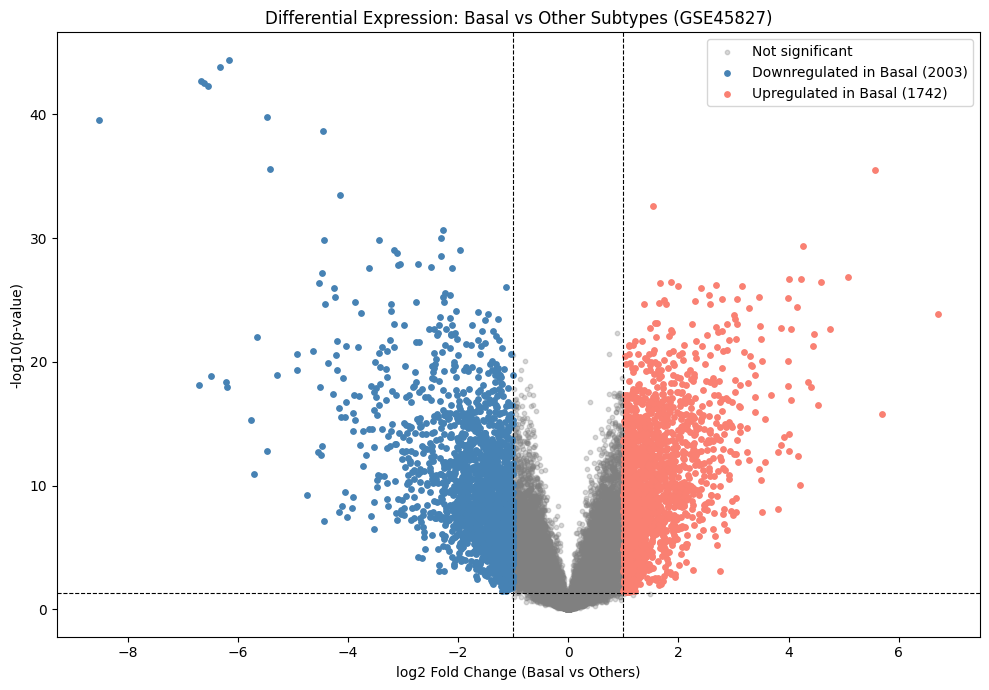

Volcano plot done


In [ ]:
results_df["neg_log10_pvalue"] = -np.log10(results_df["pvalue"])

plt.figure(figsize=(10, 7))

# All genes in grey
plt.scatter(results_df["log2FC"], results_df["neg_log10_pvalue"],
            color="grey", alpha=0.3, s=10, label="Not significant")

# Downregulated in Basal = blue
down = results_df[(results_df["pvalue"] < pvalue_threshold) &
                  (results_df["log2FC"] < -log2fc_threshold)]
plt.scatter(down["log2FC"], down["neg_log10_pvalue"],
            color="steelblue", s=15, label=f"Downregulated in Basal ({len(down)})")

# Upregulated in Basal = red
up = results_df[(results_df["pvalue"] < pvalue_threshold) &
                (results_df["log2FC"] > log2fc_threshold)]
plt.scatter(up["log2FC"], up["neg_log10_pvalue"],
            color="salmon", s=15, label=f"Upregulated in Basal ({len(up)})")

# Threshold lines
plt.axhline(y=-np.log10(pvalue_threshold), color="black", linestyle="--", linewidth=0.8)
plt.axvline(x=log2fc_threshold, color="black", linestyle="--", linewidth=0.8)
plt.axvline(x=-log2fc_threshold, color="black", linestyle="--", linewidth=0.8)

plt.xlabel("log2 Fold Change (Basal vs Others)")
plt.ylabel("-log10(p-value)")
plt.title("Differential Expression: Basal vs Other Subtypes (GSE45827)")
plt.legend()
plt.tight_layout()
plt.savefig("volcano_plot.png", dpi=150)
plt.show()
print("Volcano plot done")

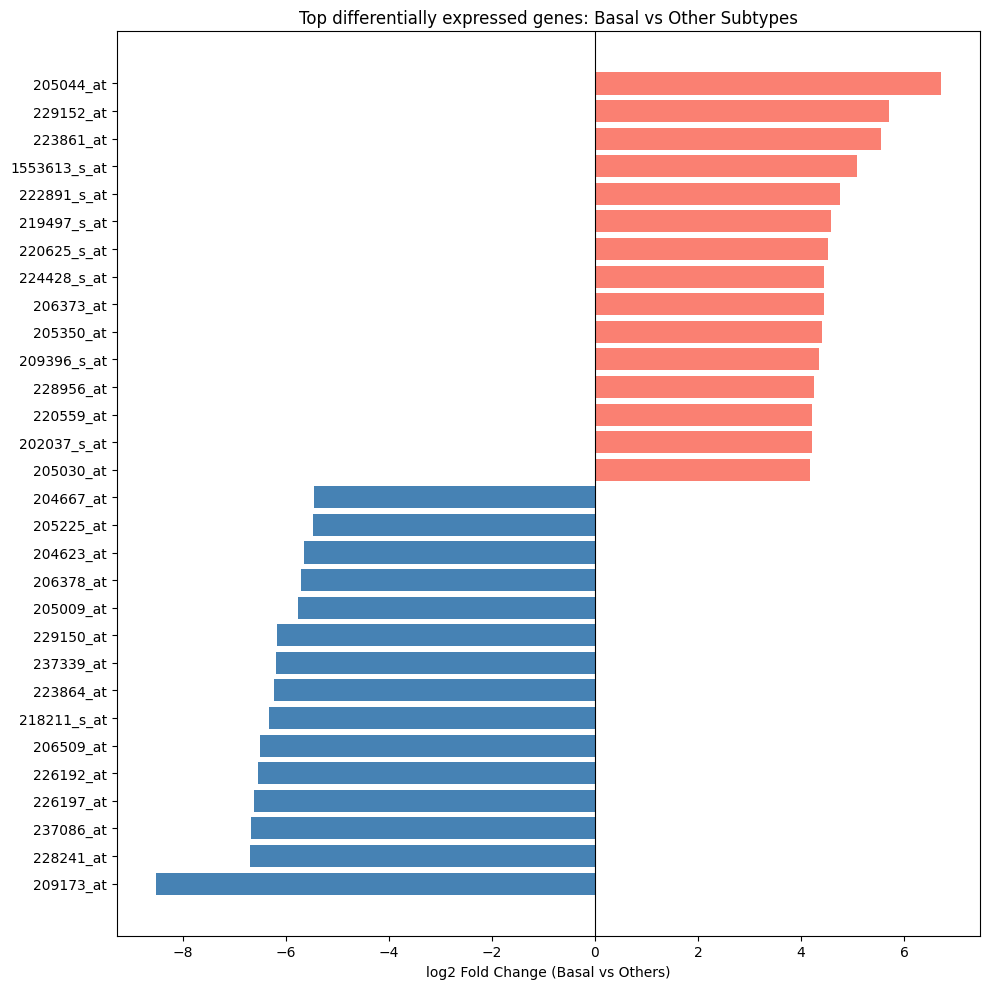

Top genes chart done


In [ ]:
top_up = significant.nlargest(15, "log2FC")
top_down = significant.nsmallest(15, "log2FC")
top_genes = pd.concat([top_up, top_down]).sort_values("log2FC")

plt.figure(figsize=(10, 10))
colors = ["steelblue" if x < 0 else "salmon" for x in top_genes["log2FC"]]
plt.barh(top_genes["gene"], top_genes["log2FC"], color=colors)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.xlabel("log2 Fold Change (Basal vs Others)")
plt.title("Top differentially expressed genes: Basal vs Other Subtypes")
plt.tight_layout()
plt.savefig("top_genes.png", dpi=150)
plt.show()
print("Top genes chart done")

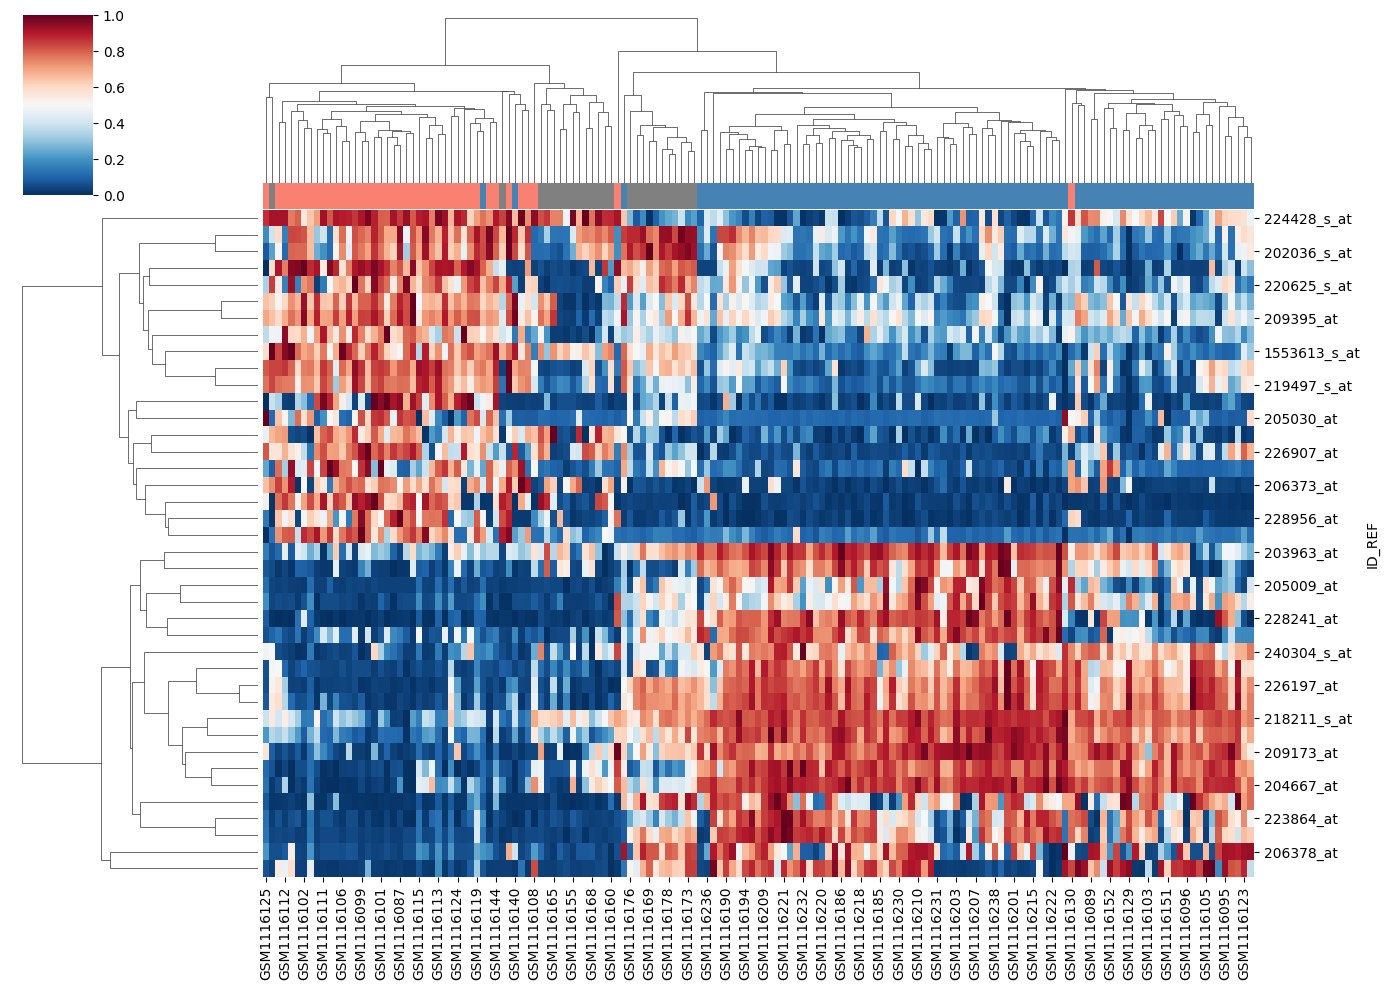

Heatmap done


In [ ]:
top40_genes = significant.nlargest(20, "log2FC")["gene"].tolist() + \
              significant.nsmallest(20, "log2FC")["gene"].tolist()

heatmap_data = expression_data.loc[top40_genes]

# Color bar: salmon = Basal, steelblue = other subtypes
sample_colors = []
for col in heatmap_data.columns:
    if col in basal_samples:
        sample_colors.append("salmon")
    elif col in other_samples:
        sample_colors.append("steelblue")
    else:
        sample_colors.append("grey")

sns.clustermap(heatmap_data,
               col_colors=sample_colors,
               cmap="RdBu_r",
               standard_scale=0,
               figsize=(14, 10))
plt.savefig("heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap done")

In [ ]:
# Save the significant genes to a file so you have the actual list
significant.to_csv("significant_DEGs.csv", index=False)
results_df.to_csv("all_genes_results.csv", index=False)

print(f"Saved {len(significant)} significant DEGs to significant_DEGs.csv")
print("Saved full results to all_genes_results.csv")
print("\nTop 10 upregulated genes in Basal:")
print(significant.nlargest(10, "log2FC")[["gene", "log2FC", "pvalue"]].to_string())
print("\nTop 10 downregulated genes in Basal:")
print(significant.nsmallest(10, "log2FC")[["gene", "log2FC", "pvalue"]].to_string())

Saved 3745 significant DEGs to significant_DEGs.csv
Saved full results to all_genes_results.csv

Top 10 upregulated genes in Basal:
               gene    log2FC        pvalue
6666      205044_at  6.714107  1.385122e-24
23025     229152_at  5.700847  1.511553e-16
18747     223861_at  5.560449  3.029386e-36
268    1553613_s_at  5.084759  1.356055e-27
17990   222891_s_at  4.758491  2.065602e-23
15927   219497_s_at  4.583032  3.368188e-27
16562   220625_s_at  4.531031  2.992476e-17
18958   224428_s_at  4.456022  5.988694e-23
7545      206373_at  4.438644  5.079983e-22
6912      205350_at  4.401356  1.080114e-18

Top 10 downregulated genes in Basal:
              gene    log2FC        pvalue
8953     209173_at -8.523483  2.773846e-40
22364    228241_at -6.698740  7.593850e-19
26600    237086_at -6.672347  1.972064e-43
20616    226197_at -6.618005  3.076219e-43
20611    226192_at -6.548913  4.783316e-43
7614     206509_at -6.494333  1.360255e-19
14729  218211_s_at -6.320341  1.584538e-44
18